# Importing the data and selecting subset
The data is first imported from the SQLite file and converted into a pandas dataframe. After that, all N/A and duplicate records are dropped, and a the dataset is subsetted randomly. 

In [1]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect("./data/properties_cleaned.db")
df = pd.read_sql_query(f"SELECT * FROM properties", conn)
conn.close()

#['bedrooms', 'building_form', 'city', 'commercial_space',
# 'days_on_market', 'energy_efficient', 'energy_label', 'fixer_upper',
# 'has_balcony', 'has_garden', 'has_heat_pump', 'has_roof_terrace',
# 'has_solar_panels', 'latitude', 'living_area', 'longitude',
# 'national_monument', 'object_type', 'plot_area_m2', 'postcode4',
# 'price', 'province', 'publication_date', 'rooms', 'url', 'year_built',
# 'has_basement', 'has_attic', 'stories'],

df = df.dropna()
df = df.drop_duplicates()
#df = df.sample(n=10000, random_state=1)

# Select subset
df = df[['price', 'bedrooms', 'building_form', 
         #'city', 
         'commercial_space',
         'days_on_market', 
         'energy_efficient', 'energy_label', 'fixer_upper',
         'has_balcony', 'has_garden', 'has_heat_pump', 'has_roof_terrace',
         'has_solar_panels', 'latitude', 'living_area', 'longitude',
         'national_monument', 
         'object_type', 'plot_area_m2', #'postcode4',
         'province', 
         #'publication_date', 
         'addresses_per_km2',
         'rooms', 'year_built',
         'has_basement', 'has_attic', 'stories']]

# Preprocessing and analyzing the data prior to modeling
Before the model can be created, the data has to be preprocessed and analyzed for things such as multicollinearity.

## Converting datatypes
All columns have to be converted to the proper datatypes to allow modeling

In [2]:
# CATEGORY
df['building_form'] = df['building_form'].astype('category')
df['object_type'] = df['object_type'].astype('category')
df['province'] = df['province'].astype('category')

# Ordinal category for energy_label
df['energy_label'] = pd.Categorical(
    df['energy_label'],
    categories=['g', 'f', 'e', 'd', 'c', 'b', 'a'],
    ordered=True
)

# BOOL
df['has_balcony'] = df['has_balcony'].astype(bool)
df['has_garden'] = df['has_garden'].astype(bool)
df['has_heat_pump'] = df['has_heat_pump'].astype(bool)
df['has_roof_terrace'] = df['has_roof_terrace'].astype(bool)
df['has_solar_panels'] = df['has_solar_panels'].astype(bool)
df['has_basement'] = df['has_basement'].astype(bool)
df['has_attic'] = df['has_attic'].astype(bool)
df['fixer_upper'] = df['fixer_upper'].astype(bool)
df['energy_efficient'] = df['energy_efficient'].astype(bool)
df['commercial_space'] = df['commercial_space'].astype(bool)
df['national_monument'] = df['national_monument'].astype(bool)

# INT
df['rooms'] = df['rooms'].astype(int)
df['year_built'] = df['year_built'].astype(int)
df['living_area'] = df['living_area'].astype(int)
df['plot_area_m2'] = df['plot_area_m2'].astype(int)
df['days_on_market'] = df['days_on_market'].astype(int)
df['bedrooms'] = df['bedrooms'].astype(int)
df['stories'] = df['stories'].astype(int)
df['addresses_per_km2'] = df['addresses_per_km2'].astype(int)

# FLOAT
df['latitude'] = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)
df['price'] = df['price'].str.replace('€', '').str.replace('.', '').astype(float)

# print data types
print(df.dtypes)

price                 float64
bedrooms                int64
building_form        category
commercial_space         bool
days_on_market          int64
energy_efficient         bool
energy_label         category
fixer_upper              bool
has_balcony              bool
has_garden               bool
has_heat_pump            bool
has_roof_terrace         bool
has_solar_panels         bool
latitude              float64
living_area             int64
longitude             float64
national_monument        bool
object_type          category
plot_area_m2            int64
province             category
addresses_per_km2       int64
rooms                   int64
year_built              int64
has_basement             bool
has_attic                bool
stories                 int64
dtype: object


In [3]:
print(len(df))

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Remove outliers for specified columns
for col in ['bedrooms', 'living_area', 'plot_area_m2', 'rooms', 'year_built', 'stories', 'price']:
    df = remove_outliers_iqr(df, col)
print(len(df))

144662
120601


## Check for Multicolinearity
Multicollinearity doesnt impact rf, but important for interpretting 

In [4]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

numeric_vars = df.select_dtypes(include=['number']).drop(columns='price')
X = add_constant(numeric_vars)  # A constant is added
 
# Compute VIF for each numeric feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)  # Sort by VIF values

print(vif_data)

              feature           VIF
0               const  17508.676255
8               rooms      5.631441
1            bedrooms      5.544181
4         living_area      2.870412
6        plot_area_m2      2.052847
7   addresses_per_km2      1.650498
10            stories      1.587029
9          year_built      1.293936
5           longitude      1.280733
3            latitude      1.128749
2      days_on_market      1.003159


The VIF values show signs of multicolliniearity for bedrooms and rooms. Therefore, the rooms variable will be converted to a non_bedroom_rooms variable. This will give the variable a different meaning, while still maintaining context.

In [5]:
if 'rooms' in df.columns:
    df['non_bedroom_rooms'] = df['rooms'] - df['bedrooms'].astype(int)
    df = df.drop(columns=['rooms'])

# XGBoost
XGBoost model

## Initial Model

In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor

y = df['price']
X = pd.get_dummies(df.drop(columns=['price']), drop_first=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []
rmse_scores = []
r2_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = LGBMRegressor(
        bagging_fraction=0.8,
        bagging_freq=0,
        feature_fraction=0.8,
        learning_rate=0.06697167353375243,
        max_depth=15,
        min_data_in_leaf=20,
        min_gain_to_split=0.01,
        n_estimators=508,
        num_leaves=64,
        subsample=1.0,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

print("CV MAE: {:.2f} ± {:.2f}".format(np.mean(mae_scores), np.std(mae_scores)))
print("CV RMSE: {:.2f} ± {:.2f}".format(np.mean(rmse_scores), np.std(rmse_scores)))
print("CV R^2: {:.3f} ± {:.3f}".format(np.mean(r2_scores), np.std(r2_scores)))

lgbm_scores = {
    'mae': mae_scores,
    'rmse': rmse_scores,
    'r2': r2_scores
}

print(lgbm_scores)



[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_gain_to_split is set=0.01, mi

In [8]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_absolute_error
from scipy.stats import randint, loguniform
import numpy as np

# Use a random subset of 10,000 samples for hyperparameter search
subset_idx = np.random.choice(X.index, size=10000, replace=False)
X_sub = X.loc[subset_idx]
y_sub = y.loc[subset_idx]

# Define model with large number of estimators (early stopping can help stop early)
LGMB = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    n_estimators=1000,
    verbose=-1
)

# Define hyperparameter search space
param_distributions = {
    "num_leaves": [31, 64, 128],
    "max_depth": [-1, 5, 10, 15],
    "min_data_in_leaf": [5, 10, 20],
    "min_gain_to_split": [0.0, 0.01, 0.1],
    "learning_rate": loguniform(0.005, 0.1),  # more granular search
    "feature_fraction": [0.8, 1.0],
    "bagging_fraction": [0.8, 1.0],
    "bagging_freq": [0, 1],
    "subsample": [0.8, 1.0],  # optional alias for bagging_fraction
    "n_estimators": randint(200, 1000)  # override if early stopping is off
}

# Define scorer (negated because sklearn maximizes score)
scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=LGMB,
    param_distributions=param_distributions,
    n_iter=10,
    scoring=scorer,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit search (NOTE: Early stopping only works if manually used with `fit()` and `eval_set`)
random_search.fit(X_sub, y_sub)

# Output best results
print("Best MAE (neg):", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best MAE (neg): -40913.57064811663
Best Parameters: {'bagging_fraction': 0.8, 'bagging_freq': 0, 'feature_fraction': 0.8, 'learning_rate': 0.06697167353375243, 'max_depth': 15, 'min_data_in_leaf': 20, 'min_gain_to_split': 0.01, 'n_estimators': 508, 'num_leaves': 64, 'subsample': 1.0}


## Feature Importance

### SHAP

[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_gain_to_split is set=0.01, mi

/var/folders/dm/_tq0dqfd50b73lqr6vh5dcwh0000gn/T/ipykernel_49990/3418377170.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontsize=10)


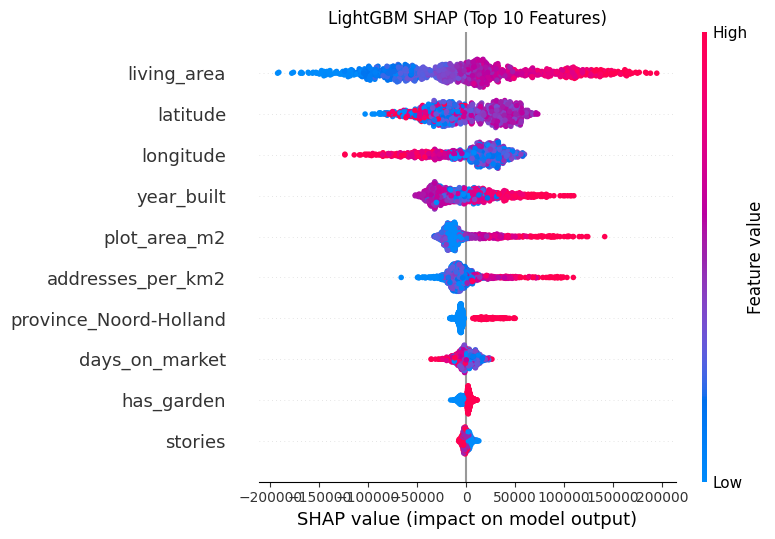


Global Feature Importance (Mean Absolute SHAP Values):
                    Feature  SHAP_Importance
11              living_area     61675.608531
10                 latitude     31504.893043
12                longitude     29999.489064
16               year_built     26392.706857
14             plot_area_m2     20493.273566
15        addresses_per_km2     15284.173193
35   province_Noord-Holland      9104.882328
2            days_on_market      7145.730316
6                has_garden      4070.264766
19                  stories      2432.393555
0                  bedrooms      2203.242922
9          has_solar_panels      2118.007759
3          energy_efficient      1878.462421
25           energy_label_c      1686.132741
31      province_Gelderland      1424.607316
17             has_basement      1255.949910
20        non_bedroom_rooms      1127.316648
5               has_balcony      1101.360576
22           energy_label_f      1067.874021
8          has_roof_terrace      1007.716300

In [7]:
import shap
import numpy as np
import matplotlib.pyplot as plt

subset_idx = np.random.choice(X.index, size=1000, replace=False)
X_subset = X.loc[subset_idx]
y_subset = y.loc[subset_idx]

model.fit(X_subset, y_subset)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_subset)

# Get mean absolute SHAP values for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top10_idx = np.argsort(mean_abs_shap)[-10:][::-1]
top10_features = X_subset.columns[top10_idx]


# Plot SHAP Values for the top 10 features
shap.summary_plot(shap_values[:, top10_idx], X_subset.iloc[:, top10_idx], plot_type="dot", show=False)
plt.title("LightGBM SHAP (Top 10 Features)")
plt.tight_layout()
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontsize=10)
plt.savefig("./plots/lightgbm_shap_10.png", dpi=300, bbox_inches='tight')
plt.show()

# Print Global Feature Importance (Mean absolute SHAP values)
feature_importance = pd.DataFrame({
    'Feature': X_subset.columns,
    'SHAP_Importance': mean_abs_shap
})
feature_importance = feature_importance.sort_values('SHAP_Importance', ascending=False)
print("\nGlobal Feature Importance (Mean Absolute SHAP Values):")
print(feature_importance)

import json
# Print top 10 features and their importance scores in JSON format
top_10_features = {row['Feature']: row['SHAP_Importance'] for row in feature_importance.head(10).to_dict('records')}
print("\nTop 10 Features and SHAP Values (JSON):")
print(json.dumps(top_10_features, indent=4))

In [8]:
import json
# Print top 10 features and their importance scores in JSON format
top_10_features = {row['Feature']: row['SHAP_Importance'] for row in feature_importance.to_dict('records')}
print("\nTop 10 Features and SHAP Values (JSON):")
print(json.dumps(top_10_features, indent=4))


Top 10 Features and SHAP Values (JSON):
{
    "living_area": 61675.608531404796,
    "latitude": 31504.893043055592,
    "longitude": 29999.48906383262,
    "year_built": 26392.70685683205,
    "plot_area_m2": 20493.273565913853,
    "addresses_per_km2": 15284.173193054621,
    "province_Noord-Holland": 9104.8823275777,
    "days_on_market": 7145.730315528693,
    "has_garden": 4070.264766435939,
    "stories": 2432.393554908567,
    "bedrooms": 2203.2429218261345,
    "has_solar_panels": 2118.00775941556,
    "energy_efficient": 1878.4624214463217,
    "energy_label_c": 1686.1327408783395,
    "province_Gelderland": 1424.6073160778417,
    "has_basement": 1255.9499097080566,
    "non_bedroom_rooms": 1127.3166476444635,
    "has_balcony": 1101.360576353475,
    "energy_label_f": 1067.8740209351597,
    "has_roof_terrace": 1007.7162996439374,
    "province_Utrecht": 950.1878113774894,
    "energy_label_a": 885.0634520253773,
    "object_type_House": 626.396216554403,
    "province_Gron